# Diabetes Risk Prediction System — Analyse Exploratoire des Données (EDA)

**Contexte :** un laboratoire biomédical souhaite identifier des profils de patients et estimer leur risque de diabète à partir de constantes cliniques.

**Objectif de ce notebook (Étape 1) :** comprendre la structure du jeu de données, auditer la qualité des mesures (valeurs manquantes, doublons, valeurs impossibles) et analyser les distributions, afin de justifier les choix de prétraitement de l'étape 2.

**Sommaire**
0. Configuration
1. Chargement des données
2. Structure du jeu de données
3. Valeurs manquantes, doublons et zéros biologiques
4. Distributions et asymétrie
5. Synthèse et décisions pour le prétraitement

## 0. Configuration

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import KNNImputer, SimpleImputer, IterativeImputer
from sklearn.preprocessing import StandardScaler
import joblib

MODELS_DIR = Path("../models")

# --- Chemins ---
DATA_FILE = Path("../data/raw/dataset-diabete.csv")

# --- Reproductibilité ---
RANDOM_STATE = 42

# --- Colonnes pour lesquelles une valeur de 0 est physiologiquement impossible ---
ZERO_AS_MISSING = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

MIN_BLOOD_PRESSURE = 40
MAX_SKIN_THICKNESS = 80

# Variables fortement asymétriques à droite -> transformation logarithmique
LOG_COLUMNS = ["Insulin", "DiabetesPedigreeFunction"]

# Variables retenues pour le clustering
SELECTED_FEATURES = ["Glucose", "BMI", "DiabetesPedigreeFunction", "Age", "Insulin"]

OPTIMAL_K = 2

RISK_THRESHOLDS = {"Glucose": 126, "BMI": 30, "DiabetesPedigreeFunction": 0.5}

# --- Affichage ---
sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", "{:.2f}".format)

## 1. Chargement des données

In [2]:
# index_col=0 : la première colonne du CSV est un ancien index sauvegardé, pas une variable
df = pd.read_csv(DATA_FILE, index_col=0)

print(f"Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"Colonnes   : {df.columns.tolist()}")
df.head()

Dimensions : 768 lignes × 8 colonnes
Colonnes   : ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.60,0.63,50
1,1,85,66,29,0,26.60,0.35,31
2,8,183,64,0,0,23.30,0.67,32
3,1,89,66,23,94,28.10,0.17,21
4,0,137,40,35,168,43.10,2.29,33


### Observations
- Le fichier contient une première colonne sans nom (`Unnamed: 0`) : c'est un **ancien index** sauvegardé dans le CSV. Il est chargé comme index (`index_col=0`) pour ne pas être analysé comme une variable.
- Le jeu de données compte **768 patientes et 8 variables**.
- `Pregnancies` est présente dans le dataset mais **ne figure pas dans la liste des variables du brief** : son utilisation pour le clustering devra être décidée et justifiée.
- Il n'existe **aucune variable cible** (pas de colonne de diagnostic) : les groupes de risque devront être construits par apprentissage non supervisé (K-Means).

## 2. Structure du jeu de données

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 48.1 KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.00,3.85,3.37,0.00,1.00,3.00,6.00,17.00
Glucose,768.00,120.89,31.97,0.00,99.00,117.00,140.25,199.00
BloodPressure,768.00,69.11,19.36,0.00,62.00,72.00,80.00,122.00
SkinThickness,768.00,20.54,15.95,0.00,0.00,23.00,32.00,99.00
Insulin,768.00,79.80,115.24,0.00,0.00,30.50,127.25,846.00
BMI,768.00,31.99,7.88,0.00,27.30,32.00,36.60,67.10
DiabetesPedigreeFunction,768.00,0.47,0.33,0.08,0.24,0.37,0.63,2.42
Age,768.00,33.24,11.76,21.00,24.00,29.00,41.00,81.00


### Observations
- Toutes les variables sont **numériques** (6 entières, 2 décimales) : aucun encodage de variable catégorielle n'est nécessaire.
- Aucune valeur `NaN` n'est signalée (`Non-Null Count` = 768 partout).
- La ligne **min** révèle des valeurs de **0** pour `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin` et `BMI`, ce qui est physiologiquement impossible (analysé en section 3).
- `Age` démarre à **21 ans** : la population étudiée est exclusivement adulte, le modèle ne sera donc pas valable pour des patients mineurs.
- `Insulin` présente un maximum de **846** pour une médiane de 30,5 et un 3ᵉ quartile de 127 : forte dispersion et valeurs extrêmes probables (à traiter en étape 2).

## 3. Valeurs manquantes, doublons et zéros biologiques

In [5]:
nb_missing = int(df.isna().sum().sum())
nb_duplicates = int(df.duplicated().sum())

print(f"Valeurs NaN explicites : {nb_missing}")
print(f"Lignes dupliquées      : {nb_duplicates}")

Valeurs NaN explicites : 0
Lignes dupliquées      : 0


In [6]:
zeros_mask = df[ZERO_AS_MISSING] == 0

zeros_report = pd.DataFrame({
    "nb_zeros": zeros_mask.sum(),
    "pct_zeros": zeros_mask.mean() * 100,
}).sort_values("pct_zeros", ascending=False)

zeros_report

,nb_zeros,pct_zeros
Insulin,374,48.70
SkinThickness,227,29.56
BloodPressure,35,4.56
BMI,11,1.43
Glucose,5,0.65


### Observations
- Aucune valeur `NaN` explicite et **aucun doublon** (test fiable maintenant que l'ancien index n'est plus une colonne).
- En revanche, des **valeurs manquantes implicites codées par 0** existent dans 5 colonnes où ce chiffre est physiologiquement impossible :

| Variable | Zéros | % |
|---|---|---|
| `Insulin` | 374 | 48,7 % |
| `SkinThickness` | 227 | 29,6 % |
| `BloodPressure` | 35 | 4,6 % |
| `BMI` | 11 | 1,4 % |
| `Glucose` | 5 | 0,7 % |

- **Hypothèse :** ces zéros correspondent à des mesures non réalisées plutôt qu'à des valeurs réelles.
- Les zéros de `Pregnancies` sont en revanche **plausibles** (patientes sans grossesse) et ne seront pas traités.
-  `Insulin` est manquante pour **près d'une patiente sur deux** : son traitement sera une décision clé de l'étape 2.

## 4. Distributions et asymétrie (skewness)

In [7]:
def interpret_skew(value: float) -> str:
    """Traduit un coefficient d'asymétrie en interprétation lisible."""
    if abs(value) < 0.5:
        return "Symétrique"
    force = "modérée" if abs(value) < 1 else "forte"
    direction = "droite" if value > 0 else "gauche"
    return f"Asymétrie {force} à {direction}"


df_zeros_as_nan = df.copy()
df_zeros_as_nan[ZERO_AS_MISSING] = df_zeros_as_nan[ZERO_AS_MISSING].replace(0, np.nan)

skew_df = pd.DataFrame({
    "skew_brut": df.skew(),
    "skew_sans_zeros": df_zeros_as_nan.skew(),  # skew() ignore les NaN
}).round(2)
skew_df["interpretation"] = skew_df["skew_sans_zeros"].apply(interpret_skew)

skew_df.sort_values("skew_sans_zeros", ascending=False)

,skew_brut,skew_sans_zeros,interpretation
Insulin,2.27,2.17,Asymétrie forte à droite
DiabetesPedigreeFunction,1.92,1.92,Asymétrie forte à droite
Age,1.13,1.13,Asymétrie forte à droite
Pregnancies,0.90,0.90,Asymétrie modérée à droite
SkinThickness,0.11,0.69,Asymétrie modérée à droite
BMI,-0.43,0.59,Asymétrie modérée à droite
Glucose,0.17,0.53,Asymétrie modérée à droite
BloodPressure,-1.84,0.13,Symétrique


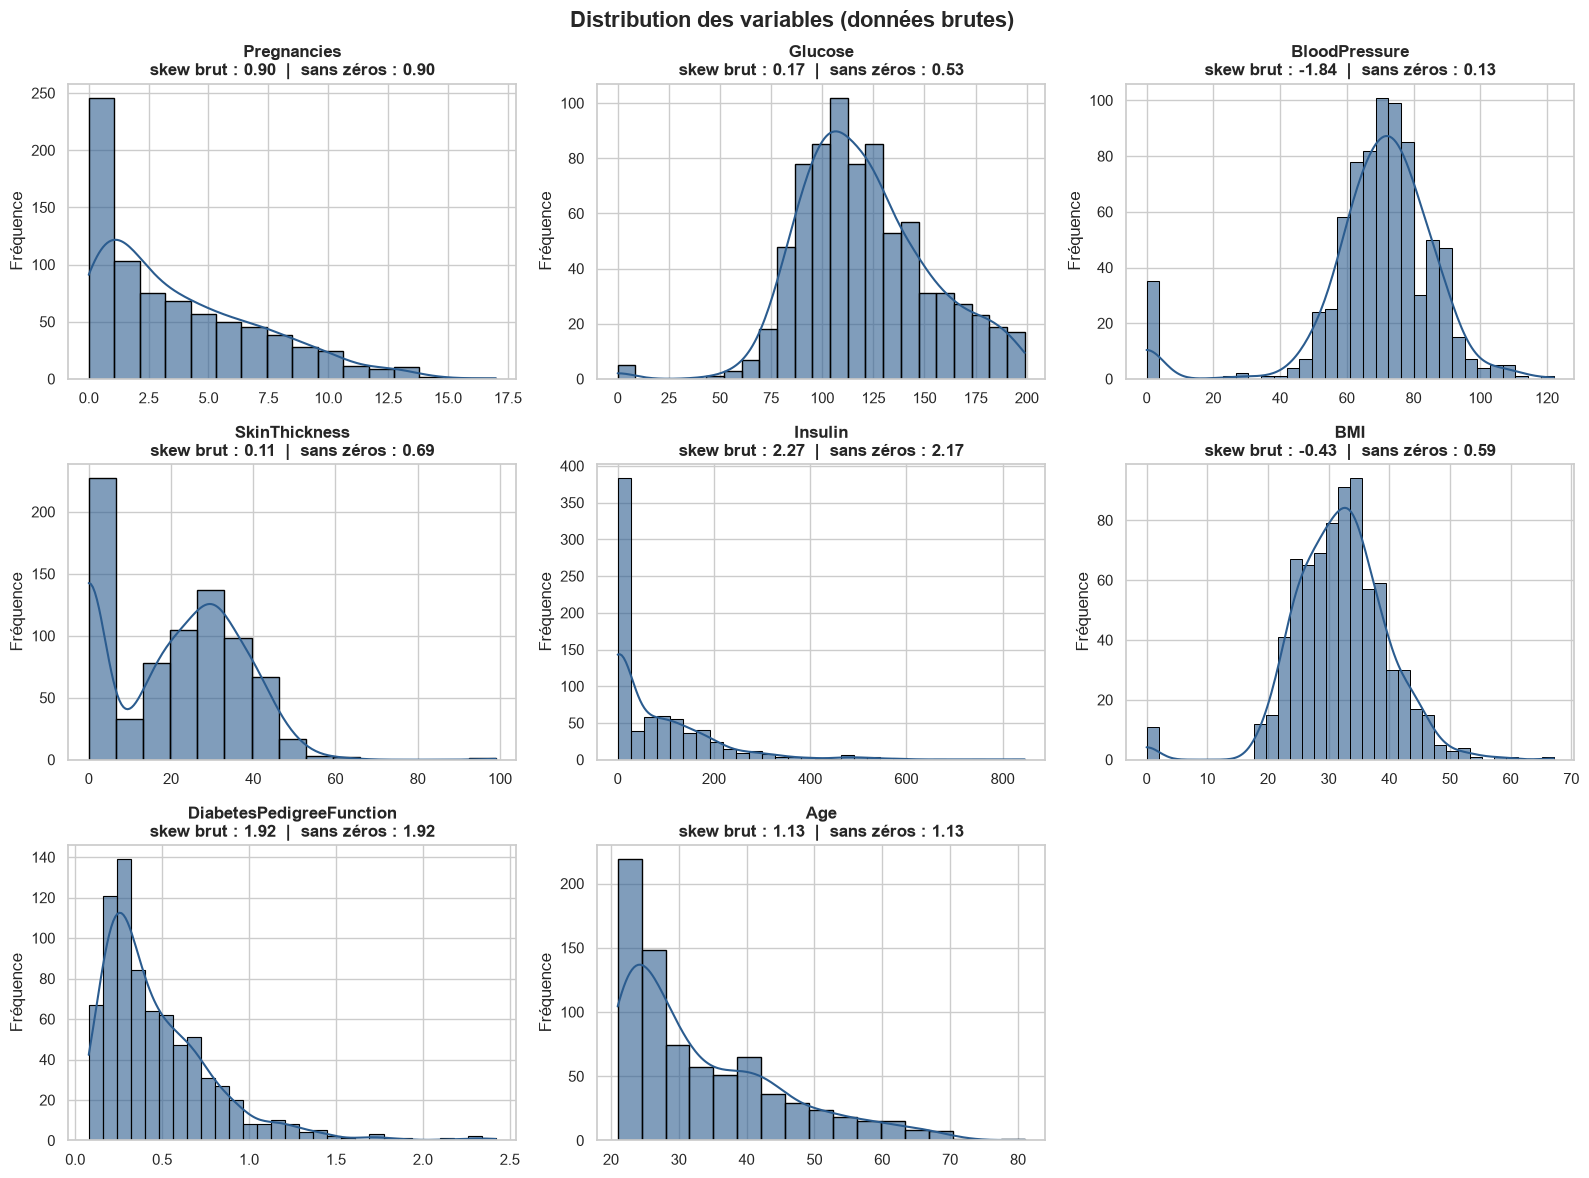

In [8]:
features = df.columns.tolist()

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 12))
axes = axes.flatten()

for ax, col in zip(axes, features):
    sns.histplot(data=df, x=col, kde=True, ax=ax,
                 color="#2b5c8f", edgecolor="black", alpha=0.6)
    ax.set_title(
        f"{col}\nskew brut : {skew_df.loc[col, 'skew_brut']:.2f}"
        f"  |  sans zéros : {skew_df.loc[col, 'skew_sans_zeros']:.2f}",
        fontweight="bold",
    )
    ax.set_xlabel("")
    ax.set_ylabel("Fréquence")

# Supprimer les sous-graphiques inutilisés (8 variables pour une grille de 9)
for ax in axes[len(features):]:
    fig.delaxes(ax)

fig.suptitle("Distribution des variables (données brutes)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

### Observations
- **Les zéros faussent fortement l'asymétrie mesurée.** La comparaison avant / après retrait des zéros le prouve :
  - `BloodPressure` passe de **−1,84 à 0,13** : la variable est en réalité **symétrique**. Seulement 35 zéros (4,6 %), isolés loin de la cloche centrée vers 70, suffisaient à simuler une forte asymétrie à gauche.
  - `BMI` passe de **−0,43 à 0,59** : le **signe s'inverse** avec seulement 11 zéros (1,4 %).
  - `SkinThickness` passe de **0,11 à 0,69** : l'apparente symétrie était une illusion. L'histogramme montre une distribution **bimodale** (pic à 0 + cloche autour de 30) dont les deux blocs se compensaient. La courbe KDE est ici trompeuse car elle lisse le vide entre 0 et 10.
  - `Glucose` passe de **0,17 à 0,53** : légère asymétrie à droite.
- **`Insulin` reste fortement asymétrique même sans les zéros (2,17)** : ce n'est pas un artefact mais sa vraie nature, avec une longue traîne vers les valeurs élevées (jusqu'à 846).
- `DiabetesPedigreeFunction` (1,92), `Age` (1,13) et `Pregnancies` (0,90) ne changent pas, ce qui est attendu puisqu'elles ne contiennent pas de zéros traités (contrôle de cohérence du code).
- **Leçon :** une statistique résumée ne remplace pas le graphique ; le skew de `SkinThickness` seul aurait conduit à une conclusion fausse.

## 5. Synthèse de l'EDA et décisions pour le prétraitement

| Constat | Impact | Action prévue à l'étape 2 |
|---|---|---|
| Ancien index dans le CSV | Faussait l'analyse et le test de doublons | Chargement avec `index_col=0`  |
| Zéros impossibles dans 5 variables | Valeurs manquantes déguisées | Remplacer les 0 par `NaN` dans `ZERO_AS_MISSING` |
| Plusieurs variables asymétriques à droite | La moyenne est tirée par les valeurs extrêmes | Imputer par la **médiane** plutôt que par la moyenne |
| `Insulin` manquante à 48,7 % | Une imputation simple créerait un pic artificiel sur la moitié des données | Comparer plusieurs stratégies (médiane, KNN, suppression de la variable) et justifier le choix |
| Distributions asymétriques (`Insulin`, `DiabetesPedigreeFunction`) | Le z-score suppose une distribution symétrique | Privilégier la méthode **IQR** pour détecter les outliers |
| Variables d'échelles très différentes (0,08 à 846) | K-Means repose sur des distances | Standardiser les variables avant le clustering |
| `Pregnancies` absente de la liste du brief | Choix des features | Décider et justifier son inclusion |


# Étape 2 — Prétraitement

## Reconstruit un DataFrame avec les colonnes et l'index d'un DataFrame de référence

In [9]:
def to_dataframe(array: np.ndarray, reference: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame(array, columns=reference.columns, index=reference.index)

## 6. Traitement des valeurs manquantes

In [10]:
implauside_rows = ((df['BloodPressure'] > 0) & (df['BloodPressure'] < MIN_BLOOD_PRESSURE)) | (df['SkinThickness'] > MAX_SKIN_THICKNESS)

print(f"Lignes avec des valeurs implausides: {implauside_rows.sum()}")
df[implauside_rows]

Lignes avec des valeurs implausides: 5


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
18,1,103,30,38,83,43.30,0.18,33
125,1,88,30,42,99,55.00,0.50,26
579,2,197,70,99,0,34.70,0.57,62
597,1,89,24,19,25,27.80,0.56,21
599,1,109,38,18,120,23.10,0.41,26


In [11]:
df_clean = df.copy()
df_clean[ZERO_AS_MISSING] = df_clean[ZERO_AS_MISSING].replace(0, np.nan)

# Valeurs physiologiquement improbables -> mesures ratées -> NaN (imputées ensuite par KNN)
df_clean.loc[df_clean["BloodPressure"] < MIN_BLOOD_PRESSURE, "BloodPressure"] = np.nan
df_clean.loc[df_clean["SkinThickness"] > MAX_SKIN_THICKNESS, "SkinThickness"] = np.nan

print(df_clean.isna().sum())
df_clean.describe()

Pregnancies                   0
Glucose                       5
BloodPressure                39
SkinThickness               228
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,768.00,763.00,729.00,540.00,394.00,757.00,768.00,768.00
mean,3.85,121.69,72.64,29.02,155.55,32.46,0.47,33.24
std,3.37,30.54,12.01,10.05,118.78,6.92,0.33,11.76
min,0.00,44.00,40.00,7.00,14.00,18.20,0.08,21.00
25%,1.00,99.00,64.00,22.00,76.25,27.50,0.24,24.00
50%,3.00,117.00,72.00,29.00,125.00,32.30,0.37,29.00
75%,6.00,141.00,80.00,36.00,190.00,36.60,0.63,41.00
max,17.00,199.00,122.00,63.00,846.00,67.10,2.42,81.00


### Méthode 1 : médiane

##

In [12]:
median_impute = SimpleImputer(strategy="median")
df_median = to_dataframe(median_impute.fit_transform(df_clean), df_clean)
df_median.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,121.66,72.60,29.02,140.67,32.46,0.47,33.24
std,3.37,30.44,11.70,8.42,86.38,6.88,0.33,11.76
min,0.00,44.00,40.00,7.00,14.00,18.20,0.08,21.00
25%,1.00,99.75,64.00,25.00,121.50,27.50,0.24,24.00
50%,3.00,117.00,72.00,29.00,125.00,32.30,0.37,29.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00
max,17.00,199.00,122.00,63.00,846.00,67.10,2.42,81.00


### Méthode 2 : KNN

In [13]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(df_clean)

knn_impute = KNNImputer(n_neighbors=5)
x_scaled_impute = knn_impute.fit_transform(x_scaled)

df_knn = to_dataframe(scaler.inverse_transform(x_scaled_impute), df_clean)

df_knn.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,121.61,72.60,28.93,153.94,32.43,0.47,33.24
std,3.37,30.47,11.81,9.12,98.25,6.89,0.33,11.76
min,0.00,44.00,40.00,7.00,14.00,18.20,0.08,21.00
25%,1.00,99.00,64.00,22.80,88.95,27.50,0.24,24.00
50%,3.00,117.00,72.00,29.00,130.00,32.19,0.37,29.00
75%,6.00,140.25,80.00,35.00,193.05,36.60,0.63,41.00
max,17.00,199.00,122.00,63.00,846.00,67.10,2.42,81.00


### Méthode 3 : MICE

In [14]:
mice_imputer = IterativeImputer(max_iter=10,min_value=df_clean.min().values, max_value=df_clean.max().values, random_state=RANDOM_STATE)
df_mice = to_dataframe(mice_imputer.fit_transform(df_clean), df_clean)
df_mice.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,121.64,72.58,28.73,152.52,32.44,0.47,33.24
std,3.37,30.47,11.77,9.19,97.21,6.88,0.33,11.76
min,0.00,44.00,40.00,7.00,14.00,18.20,0.08,21.00
25%,1.00,99.00,64.00,22.00,89.90,27.50,0.24,24.00
50%,3.00,117.00,72.00,28.20,130.55,32.15,0.37,29.00
75%,6.00,140.25,80.00,35.00,189.92,36.60,0.63,41.00
max,17.00,199.00,122.00,63.00,846.00,67.10,2.42,81.00


Médiane  | NaN restants : 0 | min Insulin : 14.00
KNN      | NaN restants : 0 | min Insulin : 14.00
MICE     | NaN restants : 0 | min Insulin : 14.00


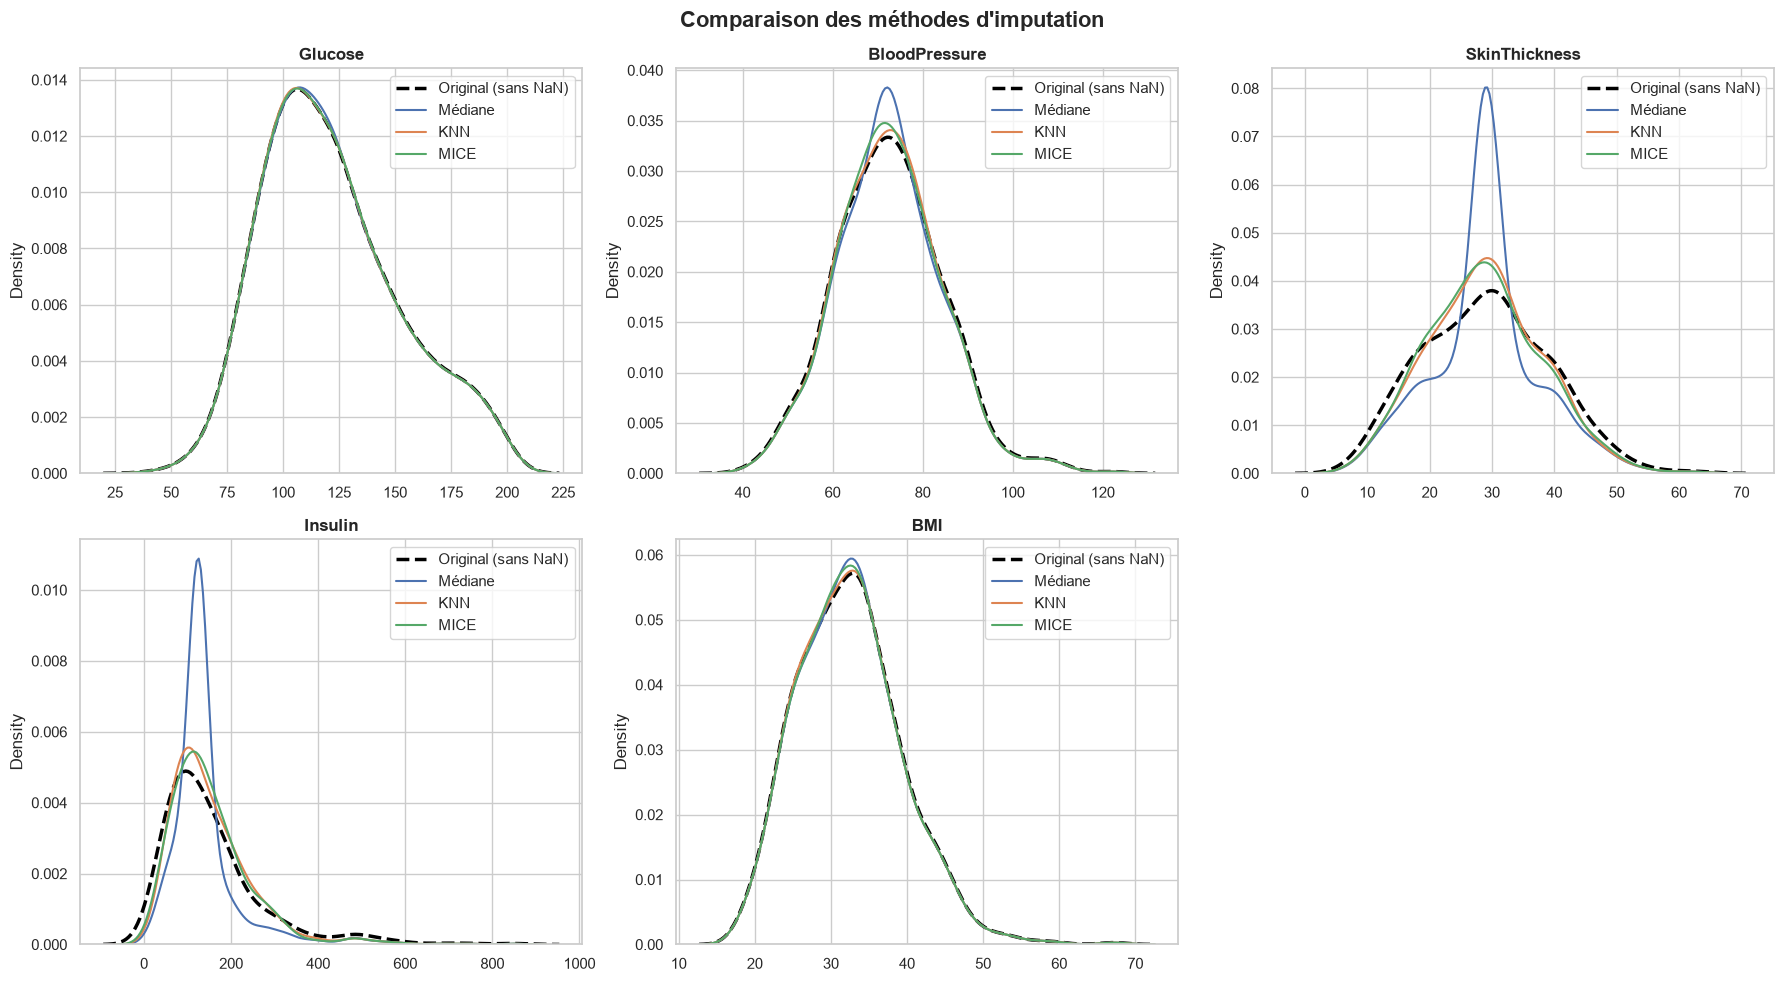

In [15]:
imputed = {"Médiane": df_median, "KNN": df_knn, "MICE": df_mice}

for name, data in imputed.items():
    print(f"{name:<8} | NaN restants : {data.isna().sum().sum()} | min Insulin : {data['Insulin'].min():.2f}")

methods = {"Original (sans NaN)": df_clean, **imputed}

std_comparison = pd.DataFrame(
    {name: data[ZERO_AS_MISSING].std() for name, data in methods.items()}
).round(2)
std_comparison


fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, ZERO_AS_MISSING):
    for label, data in methods.items():
        is_reference = label.startswith("Original")
        sns.kdeplot(
            data[col].dropna(), ax=ax, label=label,
            color="black" if is_reference else None,
            linestyle="--" if is_reference else "-",
            linewidth=2.5 if is_reference else 1.5,
        )
    ax.set_title(col, fontweight="bold")
    ax.set_xlabel("")
    ax.legend()

for ax in axes[len(ZERO_AS_MISSING):]:   # supprime la 6ᵉ case vide
    fig.delaxes(ax)

fig.suptitle("Comparaison des méthodes d'imputation", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

### Observations — Choix de la méthode d'imputation

- **Glucose, BloodPressure, BMI** : peu de valeurs manquantes (5, 35, 11), les trois méthodes donnent des courbes identiques à l'original.
- **SkinThickness et Insulin** : la **médiane** crée un pic artificiel (densité environ 2 fois plus haute que l'original), car des centaines de patientes reçoivent la même valeur. L'écart-type d'Insulin chute de 118,78 à 86,38.
- **KNN et MICE** restent proches de la distribution d'origine et donnent des résultats quasi identiques.

**Méthode retenue : KNN (k = 5)**, car :
- il estime chaque valeur à partir de patientes au profil similaire ;
- il ne peut pas produire de valeur hors de l'intervalle observé (MICE a produit une insuline négative sans bornes) ;

**Limite** : KNN nécessite une standardisation préalable, car il repose sur des distances.

In [16]:
df_impute = df_knn.copy()

## 7. Détection des outliers

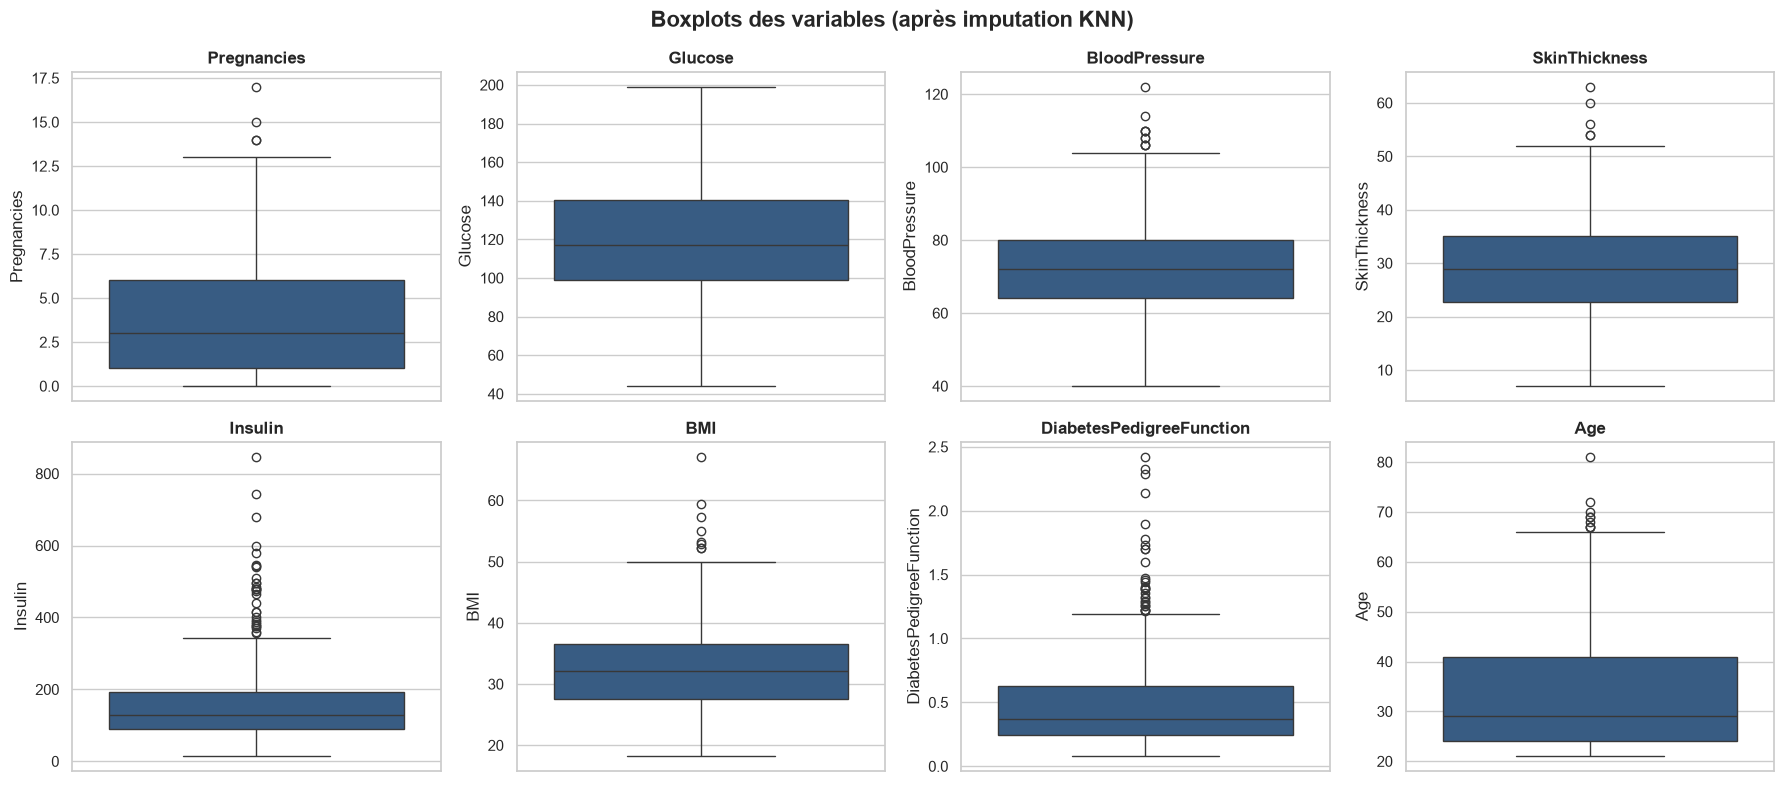

In [17]:
features = df_impute.columns.tolist()

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(18,8))

axes = axes.flatten()

for ax, col in zip(axes, features):
    sns.boxplot(y=df_impute[col], ax=ax, color="#2b5c8f")
    ax.set_title(col, fontweight="bold")
    ax.set_label=""

fig.suptitle("Boxplots des variables (après imputation KNN)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


In [18]:
# IQR
def iqr_outliers_mask(series: pd.Series, factor:float=1.5)-> pd.Series:
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - factor * iqr, q3 + factor * iqr
    return (series < lower) | (series > upper)

In [19]:
# Z-Score
def zscore_outliers_mask(series:pd.Series, threshold:float=3)->pd.Series:
    return np.abs(stats.zscore(series)) > threshold

In [20]:
iqr_mask = pd.DataFrame({col:iqr_outliers_mask(df_impute[col]) for col in features})
iqr_mask.sum()


Pregnancies                  4
Glucose                      0
BloodPressure               10
SkinThickness                5
Insulin                     29
BMI                          8
DiabetesPedigreeFunction    29
Age                          9
dtype: int64

In [21]:
zscore_mask = pd.DataFrame({col:zscore_outliers_mask(df_impute[col]) for col in features})
zscore_mask.sum()


Pregnancies                  4
Glucose                      0
BloodPressure                5
SkinThickness                2
Insulin                     17
BMI                          5
DiabetesPedigreeFunction    11
Age                          5
dtype: int64

In [22]:
outliers_report = pd.DataFrame({
    "outliers_iqr": iqr_mask.sum(),
    "outliers_zscore": zscore_mask.sum(),
}).sort_values("outliers_iqr", ascending=False)

outliers_report

,outliers_iqr,outliers_zscore
DiabetesPedigreeFunction,29,11
Insulin,29,17
BloodPressure,10,5
Age,9,5
BMI,8,5
SkinThickness,5,2
Pregnancies,4,4
Glucose,0,0


In [23]:
rows_with_outliers = iqr_mask.any(axis=1)
nb_rows = rows_with_outliers.sum()

print(f"Patientes avec au moins un outlier (IQR) : {nb_rows} / {len(df_impute)} "
      f"({nb_rows / len(df_impute) * 100:.1f} %)")

Patientes avec au moins un outlier (IQR) : 85 / 768 (11.1 %)


### Observations — Traitement des outliers

- **Détection** : la méthode IQR détecte plus d'outliers que le z-score, car le z-score repose sur
  la moyenne et l'écart-type, eux-mêmes gonflés par les valeurs extrêmes. IQR, basé sur les
  quartiles, est plus adapté à nos distributions asymétriques.
- **Supprimer les lignes concernées** ferait perdre 88 patientes (11,5 %), en priorité les profils
  à risque. Aucune ligne n'est donc supprimée.
- **Valeurs improbables** (5 patientes) : tension diastolique < 40 mm Hg (état de choc) et pli
  cutané > 80 mm (au-delà de la capacité des calipers standard). Considérées comme des mesures
  ratées : remplacées par NaN puis imputées par KNN.
- **Valeurs extrêmes réelles** : conservées (ex. insuline à 2 h de 846 µU/mL = résistance sévère
  à l'insuline, profil réel à haut risque).
- **Transformation logarithmique** de `Insulin` et `DiabetesPedigreeFunction` : contrairement au
  capping, elle réduit l'influence des valeurs extrêmes **sans perdre l'ordre** entre elles.
  Skew : Insulin 2,14 → −0,22 ; DiabetesPedigreeFunction 1,92 → 0,11.
- **Résultat** : 768 patientes conservées, aucune information écrasée.

## 8. Transformation logarithmique

In [24]:
df_transformed = df_impute.copy()
df_transformed[LOG_COLUMNS] = np.log(df_transformed[LOG_COLUMNS])

skew_log = pd.DataFrame({
    "skew_avant": df_impute[LOG_COLUMNS].skew(),
    "skew_apres_log": df_transformed[LOG_COLUMNS].skew(),
}).round(2)
skew_log

,skew_avant,skew_apres_log
Insulin,2.13,-0.22
DiabetesPedigreeFunction,1.92,0.11


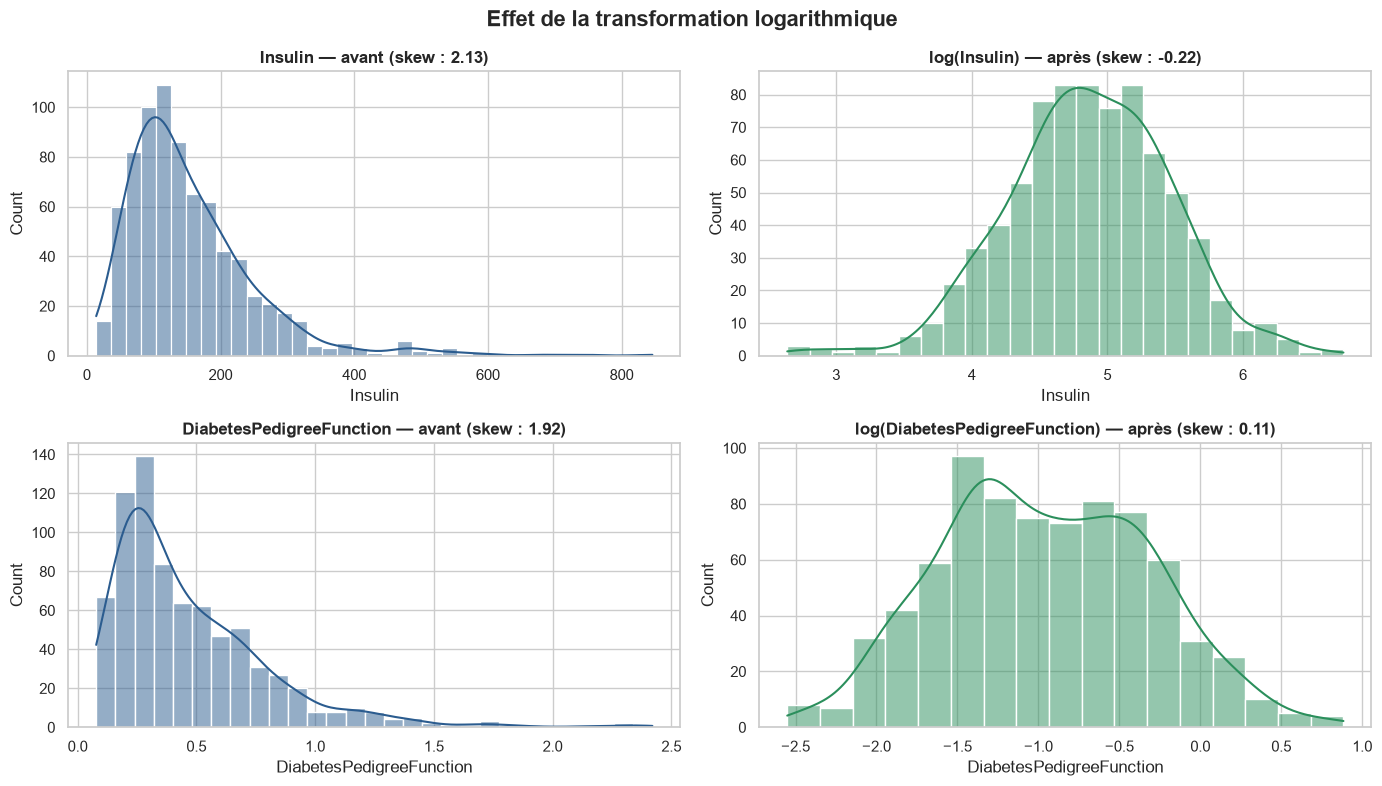

In [25]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 8))

for row, col in enumerate(LOG_COLUMNS):
    sns.histplot(df_impute[col], kde=True, ax=axes[row, 0], color="#2b5c8f")
    axes[row, 0].set_title(f"{col} — avant (skew : {skew_log.loc[col, 'skew_avant']:.2f})",
                           fontweight="bold")

    sns.histplot(df_transformed[col], kde=True, ax=axes[row, 1], color="#2b8f5c")
    axes[row, 1].set_title(f"log({col}) — après (skew : {skew_log.loc[col, 'skew_apres_log']:.2f})",
                           fontweight="bold")

fig.suptitle("Effet de la transformation logarithmique", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

### Observations — Transformation logarithmique

- Le logarithme supprime la longue traîne à droite des deux variables : leurs distributions
  deviennent approximativement symétriques (Insulin : 2,14 → −0,22 ; DiabetesPedigreeFunction : 1,92 → 0,11).
- Les valeurs extrêmes sont conservées et gardent leur ordre, mais n'écrasent plus les autres valeurs.
- Les valeurs négatives de log(DiabetesPedigreeFunction) sont normales (log d'un nombre < 1).
- `df_impute` conserve les valeurs réelles (interprétation médicale des clusters, étape 4) ;
  `df_transformed` sera utilisé pour le clustering.

## 9. Relations entre variables et sélection des features

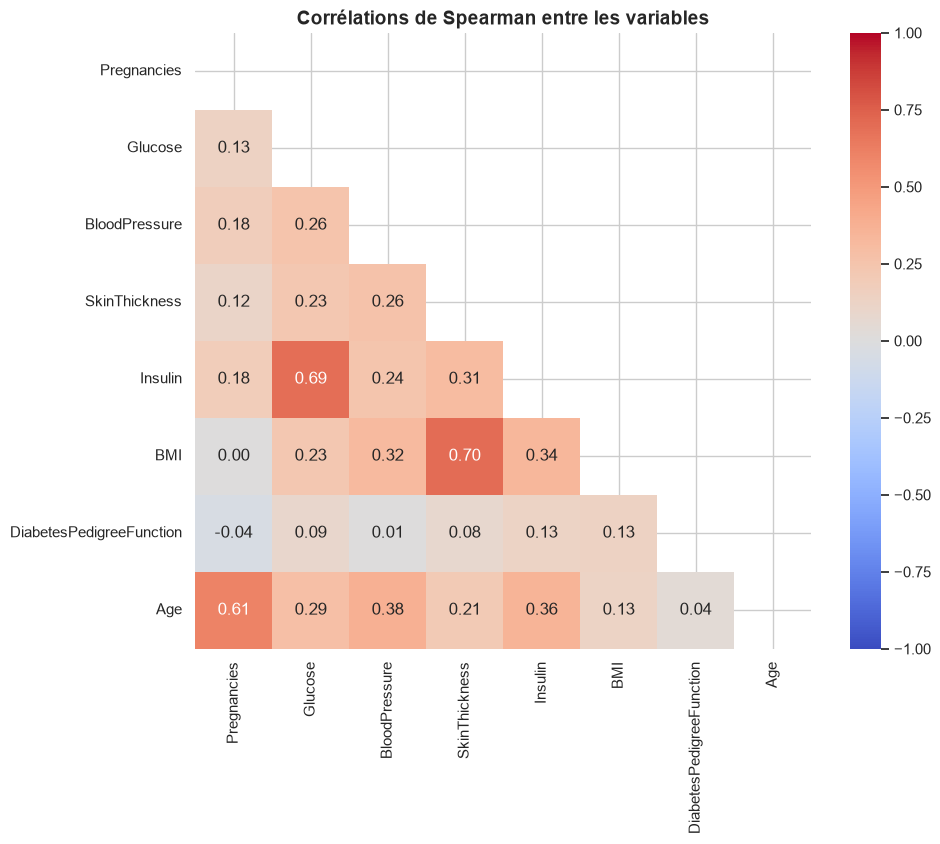

In [26]:
corr_matrix = df_transformed.corr(method="spearman")

# Masque le triangle supérieur (doublon du triangle inférieur) et la diagonale (toujours 1)
upper_mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, mask=upper_mask, annot=True, fmt=".2f",
            cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Corrélations de Spearman entre les variables", fontsize=14, fontweight="bold")
plt.show()

In [27]:
strongest_pairs = (
    corr_matrix.where(~upper_mask)          # garde uniquement le triangle inférieur
    .stack()                                # transforme la matrice en liste de paires
    .sort_values(key=abs, ascending=False)  # trie par force du lien, positif ou négatif
)
strongest_pairs.head(5)

BMI      SkinThickness   0.70
Insulin  Glucose         0.69
Age      Pregnancies     0.61
         BloodPressure   0.38
         Insulin         0.36
dtype: float64

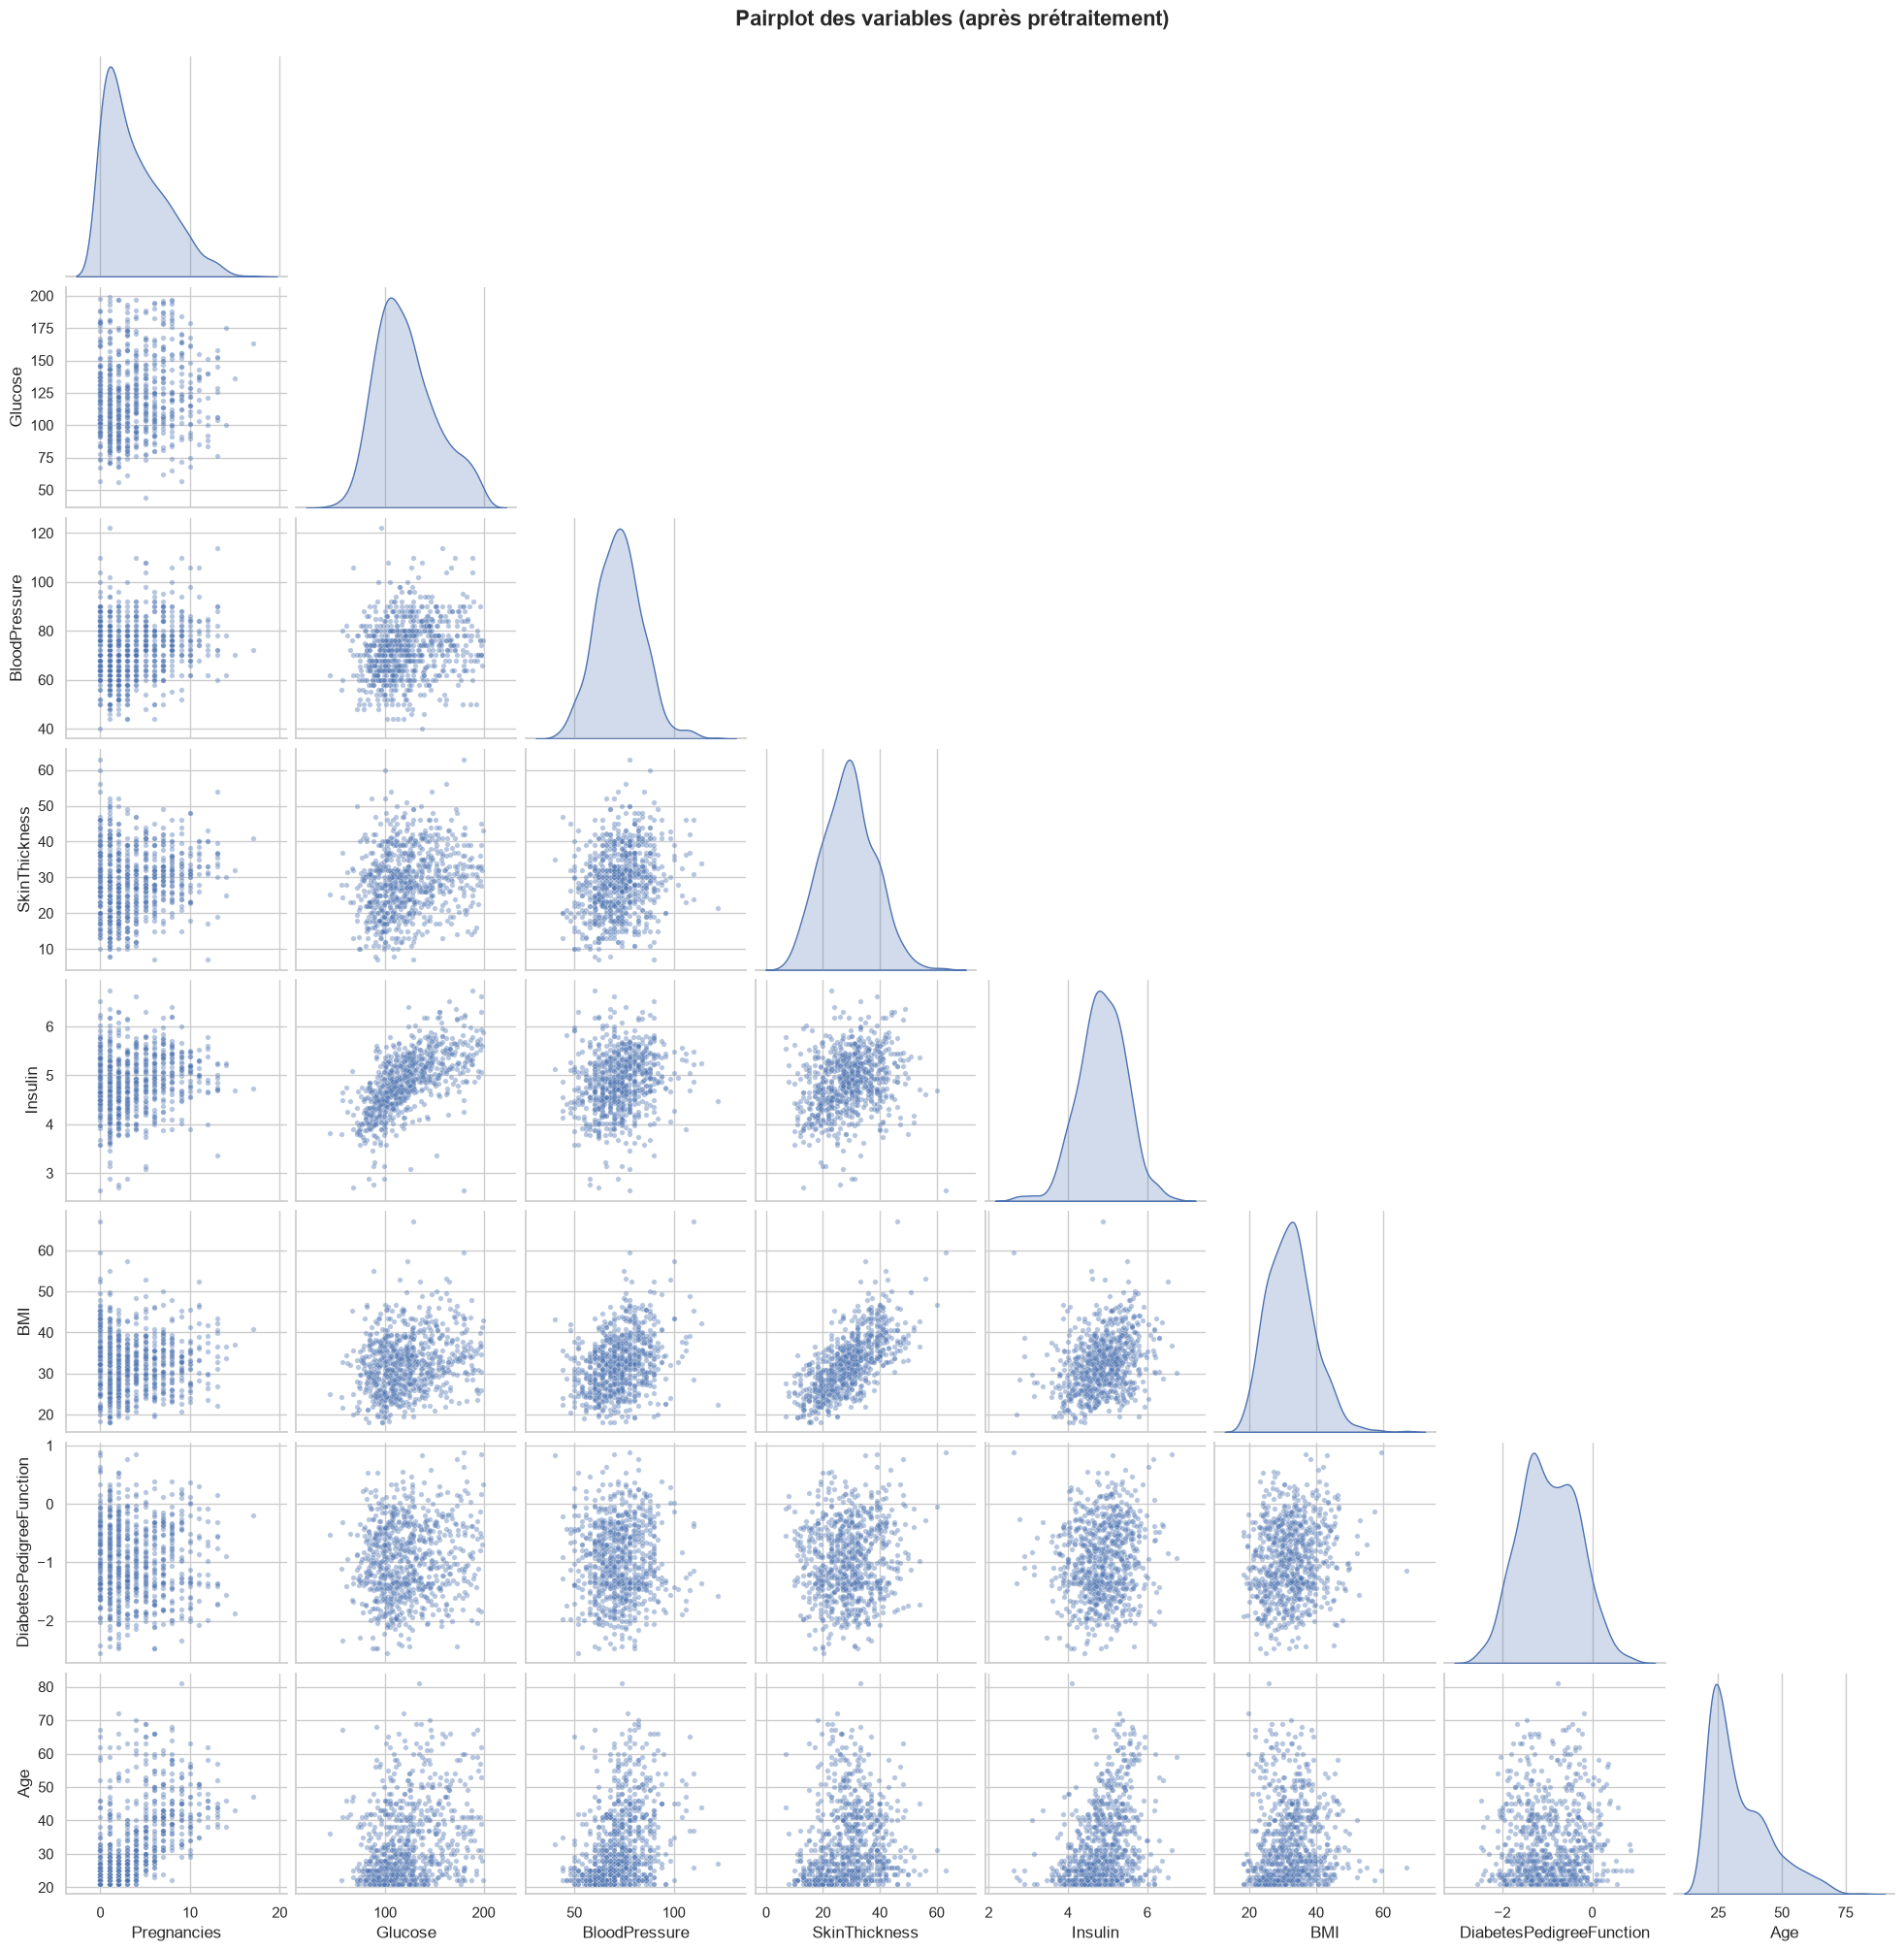

In [28]:
sns.pairplot(df_transformed, corner=True, diag_kind="kde",
             plot_kws={"alpha": 0.4, "s": 15})
plt.suptitle("Pairplot des variables (après prétraitement)", y=1.01, fontsize=16, fontweight="bold")
plt.show()

In [29]:
variability = pd.DataFrame({
    "variance": df_impute.var(),
    "cv_pct": df_impute.std() / df_impute.mean() * 100,
}).sort_values("cv_pct", ascending=False).round(2)

variability

,variance,cv_pct
Pregnancies,11.35,87.63
DiabetesPedigreeFunction,0.11,70.22
Insulin,9653.49,63.83
Age,138.30,35.38
SkinThickness,83.12,31.51
Glucose,928.59,25.06
BMI,47.48,21.25
BloodPressure,139.45,16.27


### Observations — Relations entre variables et sélection des features

**Corrélations (Spearman)** : trois paires fortement liées, toutes cohérentes médicalement :
- **BMI ↔ SkinThickness (0,70)** : les deux mesurent la masse grasse, elles sont redondantes.
- **Insulin ↔ Glucose (0,69)** : mesurées 2 h après une prise de glucose, le pancréas sécrète
  de l'insuline en réponse à la glycémie. Comme KNN a utilisé Glucose pour imputer Insulin,
  le lien a été vérifié sur les seules patientes sans valeur imputée : 0,66. Le lien est donc
  réel et non un artefact de l'imputation.
- **Age ↔ Pregnancies (0,61)** : plus une femme est âgée, plus elle a eu de grossesses.
- `DiabetesPedigreeFunction` n'est corrélée à aucune autre variable (≤ 0,13) : elle apporte une
  information unique (antécédents familiaux).

**Variabilité** : mesurée par le **coefficient de variation** (CV = écart-type / moyenne × 100),
car la variance dépend de l'unité de chaque variable (ex. variance d'Insulin = 9 653 contre 0,1
pour DiabetesPedigreeFunction) et ne permet pas de les comparer.

**Sélection** : basée sur trois critères combinés (variabilité, redondance, besoin métier).
Une sélection sur le CV seul aurait éliminé Glucose et BMI, pourtant indispensables pour
identifier le cluster à risque à l'étape 4.

| Variable | CV | Décision | Justification |
|---|---|---|---|
| Glucose | 25,1 % | ✅ Garder | Critère de risque du brief (> 126) |
| BMI | 21,2 % | ✅ Garder | Critère de risque du brief (> 30), plus fiable que SkinThickness (1,4 % imputé) |
| DiabetesPedigreeFunction | 70,2 % | ✅ Garder | Critère de risque du brief (> 0,5), forte variabilité, information unique |
| Age | 35,4 % | ✅ Garder | Variable du brief, facteur de risque reconnu |
| Insulin | 63,8 % | ✅ Garder | Forte variabilité, information distincte (résistance à l'insuline), lien avec Glucose vérifié réel |
| SkinThickness | 31,5 % | ❌ Retirer | Redondante avec BMI (0,70) et 29,6 % de valeurs imputées |
| BloodPressure | 16,3 % | ❌ Retirer | Variabilité la plus faible, absente des critères de risque |
| Pregnancies | 87,6 % | ❌ Retirer | Absente de la liste du brief, partiellement redondante avec Age (0,61) |

**Variables retenues pour le clustering** : Glucose, BMI, DiabetesPedigreeFunction, Age, Insulin.

## 10. Standardisation.

In [30]:
X = df_transformed[SELECTED_FEATURES]

cluster_scaler = StandardScaler()
X_scaled = to_dataframe(cluster_scaler.fit_transform(X), X)

X_scaled.describe().T[["mean", "std", "min", "max"]]

,mean,std,min,max
Glucose,0.00,1.00,-2.55,2.54
BMI,-0.00,1.00,-2.07,5.04
DiabetesPedigreeFunction,0.00,1.00,-2.47,2.86
Age,0.00,1.00,-1.04,4.06
Insulin,-0.00,1.00,-3.71,3.13


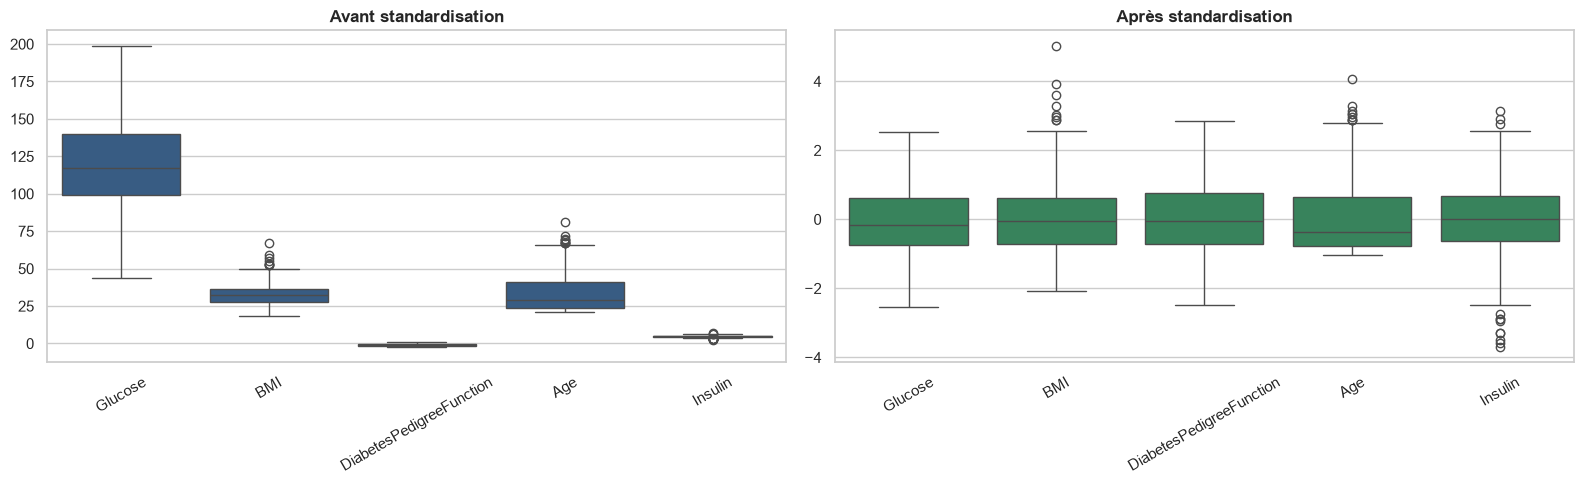

In [31]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))

sns.boxplot(data=X, ax=axes[0], color="#2b5c8f")
axes[0].set_title("Avant standardisation", fontweight="bold")

sns.boxplot(data=X_scaled, ax=axes[1], color="#2b8f5c")
axes[1].set_title("Après standardisation", fontweight="bold")

for ax in axes:
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

In [32]:
joblib.dump(cluster_scaler, MODELS_DIR / "scaler.joblib")
print(f"Scaler sauvegardé : {MODELS_DIR / 'scaler.joblib'}")

Scaler sauvegardé : ..\models\scaler.joblib


### Observations — Standardisation

- Les variables sélectionnées ont des échelles très différentes (Glucose de 44 à 199,
  log(DiabetesPedigreeFunction) de −2,5 à 0,9). Sans mise à l'échelle, K-Means formerait
  ses groupes presque uniquement selon les variables aux grandes valeurs.
- **StandardScaler** retenu : les distributions sont approximativement symétriques après la
  transformation logarithmique. Toutes les variables ont désormais une moyenne de 0 et un
  écart-type de 1, et pèsent autant dans le calcul des distances.
- Le scaler est sauvegardé (`models/scaler.joblib`) pour être réutilisé à l'identique par
  l'API et tracé dans MLflow (étape 6).

# Étape 3 — Clustering K-Means

## 11. Choix du nombre de clusters

In [33]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K_RANGE = range(2, 11)

In [34]:
result = []

for k in K_RANGE:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = kmeans.fit_predict(X_scaled)
    result.append({
        'k':k,
        'inertia':kmeans.inertia_,
        'silhouette':silhouette_score(X_scaled, labels)
    })

k_scores = pd.DataFrame(result).set_index('k')
k_scores

,inertia,silhouette
k,,
2,2779.50,0.25
3,2382.18,0.24
4,2104.06,0.20
5,1883.72,0.20
6,1742.80,0.19
7,1632.85,0.19
8,1554.56,0.18
9,1462.19,0.18
10,1390.64,0.18


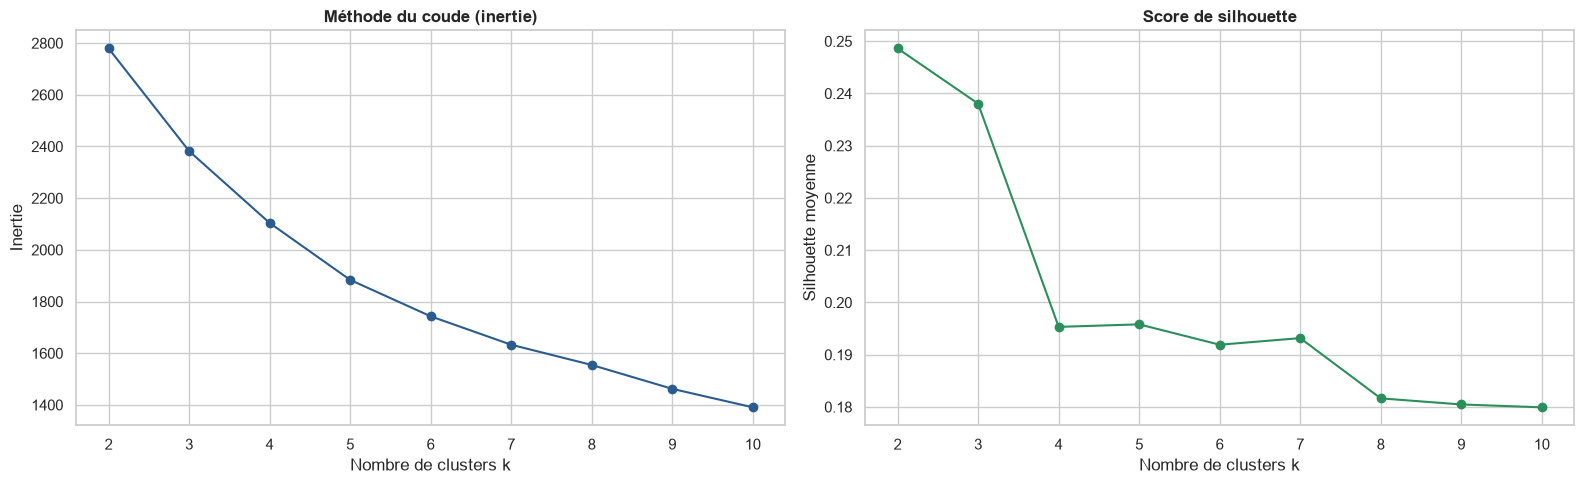

In [35]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))

axes[0].plot(k_scores.index, k_scores["inertia"], marker="o", color="#2b5c8f")
axes[0].set_title("Méthode du coude (inertie)", fontweight="bold")
axes[0].set_xlabel("Nombre de clusters k")
axes[0].set_ylabel("Inertie")

axes[1].plot(k_scores.index, k_scores["silhouette"], marker="o", color="#2b8f5c")
axes[1].set_title("Score de silhouette", fontweight="bold")
axes[1].set_xlabel("Nombre de clusters k")
axes[1].set_ylabel("Silhouette moyenne")

for ax in axes:
    ax.set_xticks(list(K_RANGE))

plt.tight_layout()
plt.show()

## 12. Entraînement du modèle K-Means

In [36]:
kmeans = KMeans(n_clusters=OPTIMAL_K, n_init=10, random_state=RANDOM_STATE)
cluster_labels = kmeans.fit_predict(X_scaled)

joblib.dump(kmeans, MODELS_DIR / "kmeans.joblib")
print(f"Inertie : {kmeans.inertia_:.2f} | Silhouette : {silhouette_score(X_scaled, cluster_labels):.3f}")

Inertie : 2779.50 | Silhouette : 0.249


In [37]:
df_clustered = df_impute.copy()
df_clustered["Cluster"] = cluster_labels

df_clustered["Cluster"].value_counts().sort_index()
# df_clustered

Cluster
0    359
1    409
Name: count, dtype: int64

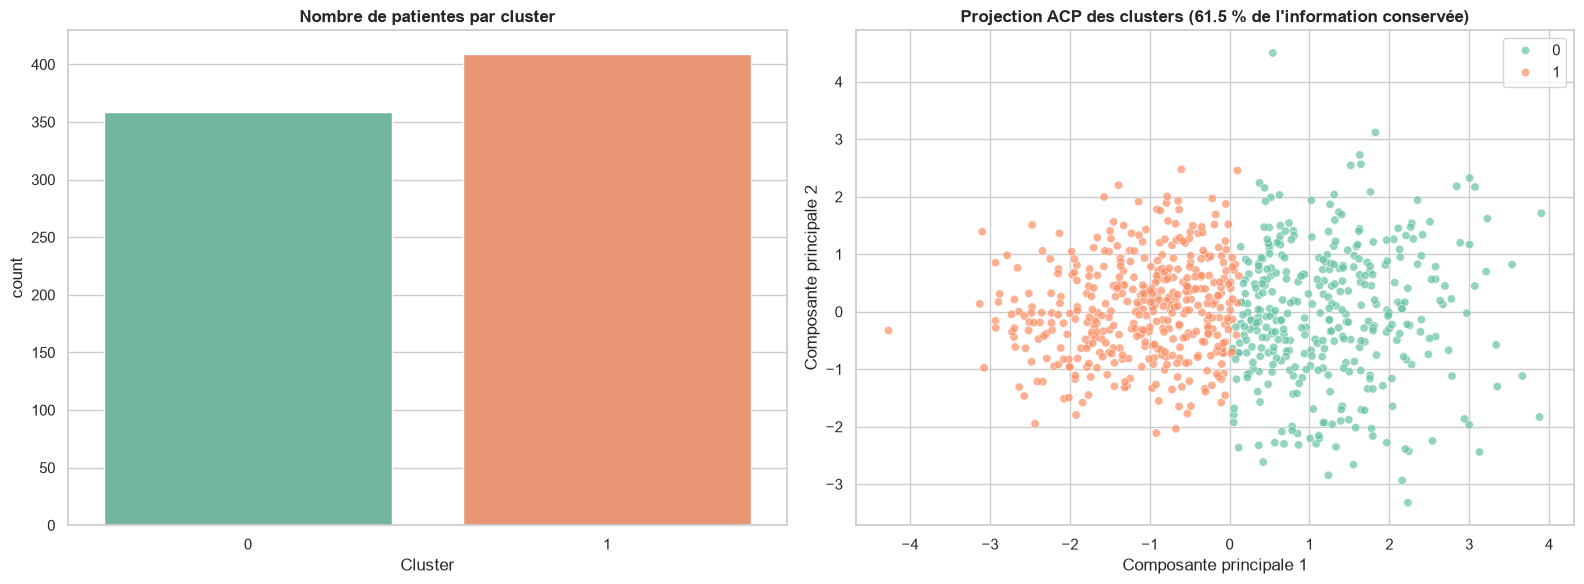

In [38]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_.sum() * 100

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

sns.countplot(x=df_clustered["Cluster"], ax=axes[0], palette="Set2", hue=df_clustered["Cluster"], legend=False)
axes[0].set_title("Nombre de patientes par cluster", fontweight="bold")

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=cluster_labels, palette="Set2", alpha=0.7, ax=axes[1])
axes[1].set_title(f"Projection ACP des clusters ({explained:.1f} % de l'information conservée)",
                  fontweight="bold")
axes[1].set_xlabel("Composante principale 1")
axes[1].set_ylabel("Composante principale 2")

plt.tight_layout()
plt.show()

# Étape 4 — Analyse des clusters

## 13. Profil des clusters

In [39]:
cluster_profile = df_clustered.groupby("Cluster")[SELECTED_FEATURES].mean().round(2)
cluster_profile["nb_patientes"] = df_clustered["Cluster"].value_counts().sort_index()

cluster_profile

,Glucose,BMI,DiabetesPedigreeFunction,Age,Insulin,nb_patientes
Cluster,,,,,,
0,143.74,35.19,0.55,39.47,220.20,359
1,102.18,30.00,0.41,27.77,95.77,409


In [40]:
threshold_check = pd.DataFrame({
    feature: cluster_profile[feature] > threshold
    for feature, threshold in RISK_THRESHOLDS.items()
})
threshold_check["haut_risque"] = threshold_check.all(axis=1)

threshold_check

,Glucose,BMI,DiabetesPedigreeFunction,haut_risque
Cluster,,,,
0,True,True,True,True
1,False,False,False,False


In [42]:
high_risk_clusters = threshold_check.index[threshold_check["haut_risque"]].tolist()

# Garde-fou : on s'attend à exactement un cluster à haut risque
if len(high_risk_clusters) != 1:
    raise ValueError(f"Attendu 1 cluster à haut risque, trouvé {len(high_risk_clusters)} : {high_risk_clusters}")

HIGH_RISK_CLUSTER = high_risk_clusters[0]
print(f"Cluster à haut risque identifié : {HIGH_RISK_CLUSTER}")

df_clustered["risk_category"] = np.where(
    df_clustered["Cluster"] == HIGH_RISK_CLUSTER, "Risque élevé", "Risque faible"
)
df_clustered["risk_category"].value_counts()

Cluster à haut risque identifié : 0


risk_category
Risque faible    409
Risque élevé     359
Name: count, dtype: int64

### Observations — Profil des clusters

| Variable | Cluster 0 | Cluster 1 | Seuil |
|---|---|---|---|
| Glucose | 143,7 | 102,2 | > 126 |
| BMI | 35,2 | 30,0 | > 30 |
| DiabetesPedigreeFunction | 0,55 | 0,41 | > 0,5 |
| Age | 39,5 | 27,8 | — |
| Insulin | 220,2 | 95,8 | — |
| Nombre de patientes | 359 | 409 | — |

- **Le cluster 0 dépasse les trois seuils critiques** : il est identifié automatiquement comme
  le cluster à **risque élevé** (359 patientes, 47 %). Son numéro est l'inverse de l'exemple du
  brief, ce qui confirme l'intérêt d'identifier le cluster par ses moyennes plutôt que par son numéro.
- Les variables hors seuils renforcent ce profil : patientes **plus âgées** (39,5 contre 27,8 ans)
  et **insuline deux fois plus élevée** (signe de résistance à l'insuline).
- Le cluster "risque faible" a un BMI moyen de 30,0, exactement au seuil de l'obésité :
  "faible" est un risque **relatif** au sein d'une population globalement en surpoids.
- **Nuance médicale** : la glycémie est mesurée 2 h après une prise de glucose. La moyenne du
  cluster à risque (143,7) se situe dans la zone d'intolérance au glucose (140–199), sous le seuil
  du diabète (≥ 200). "Risque élevé" désigne donc un **profil à surveiller**, pas un diagnostic.